# HCC Internal Diagnostics (from logs)

This notebook reads `run_log.jsonl` and analyzes the diagnostic signals logged by the HCC module.

HCC is a binary on/off switch shared across model families
(`models/common/hcc.py`), so each group below is one family's plain baseline
against its matched HCC run on the same dataset:

- `hcast_<dataset>` vs `hcast_<dataset>_hcc`
- `hrn_<dataset>` vs `hrn_<dataset>_level_marginal_hcc`
- `capsnet_<dataset>` vs `capsnet_<dataset>_hcc` (exploratory: capsule-length
  scores are read against fixed margin thresholds)
- `hiercos_<dataset>_global_softmax_ce_reg_baseline_kl_leaf` vs
  `hiercos_<dataset>_global_softmax_ce_reg_hcc`

Groups whose HCC run has not been launched yet come back empty and are skipped.
Not every family logs every diagnostic: `proj_temperature` and the
`gt_parent_mass_*` / `gt_child_rank_*` block are H-CAST-specific, while
`proj_constraint_alpha`, the residual keys, and the fine-distribution-shift keys
are emitted by the shared HCC module for all of them.

## HCC New Log Glossary

These metrics are saved in `run_log.jsonl` (`train_metrics` / `val_metrics`) and in `test_metrics.yaml`.

### Conventions

- `GT` means **ground truth** (the true dataset label).
- `pre`: distribution from `softmax(logits)` before the HCC effect.
- `post`: final scores used by metrics (`effective_logits_per_level` when present; probability diagnostics use `softmax(post)`).
- `ind`: independent decoding.
- `td`: top-down decoding.
- Level suffixes in the key names are zero-based: `level_0`/`l0` is the coarse level, `level_1`/`l1` the middle one and `level_2`/`l2` the fine one. The thesis numbers the same three levels from the root as $l=1,2,3$ with objectives $\ell_1,\ell_2,\ell_3$, so `level_0` here is $l=1$ there. The figures below are labelled by depth (coarse / middle / fine), never by the key suffix.

### Constraint state / scheduling

- `proj_constraint_alpha`: HCC constraint intensity (`0`=off, `1`=fully hard).
- `proj_temperature`: current temperature in the HCC schedule.

### Constraint residuals (projector)

- `proj_logit_residual_before_l1`: mean absolute logit-space constraint violation before correction.
  - formula: `mean(abs([M12*p2 - p1, M23*p3 - p2]))`
- `proj_logit_residual_after_l1`: same quantity after correction.
- `proj_logit_residual_reduction`: residual reduction (`before - after`).

### Fine-level distribution shift glossary

This block measures how much HCC changes the fine-level probability vector from `pre` to `post`.

- `proj_delta_l1_level_2`
  - Definition: mean `L1` distance between `p_fine_pre` and `p_fine_post`.
  - Reading: larger value = stronger redistribution of probability mass across fine classes.

- `proj_flip_rate_level_2`
  - Definition: fraction of samples where fine-level `argmax` changes (`pre -> post`).
  - Reading: larger value = HCC changes the predicted fine class more often.

- `proj_gt_prob_delta_level_2`
  - Definition: mean change on GT fine-class probability (`post - pre`).
  - Reading:
    - positive => GT fine class gained probability,
    - negative => GT fine class lost probability.

Worked example (one sample):

- `pre  = [cat 0.55, dog 0.25, fox 0.15, wolf 0.05]`
- `post = [cat 0.35, dog 0.45, fox 0.15, wolf 0.05]`

Interpretation:

- `proj_delta_l1_level_2` is large (probability moved from `cat` to `dog`).
- `proj_flip_rate_level_2` would count this as a flip (`cat -> dog`).
- If GT is `cat`, then `proj_gt_prob_delta_level_2 = 0.35 - 0.55 = -0.20` (worse for GT).

### Fine accuracy conditioned on a correct parent (middle) level

- `acc_l2_ind_given_l1_correct`: fine independent accuracy on the samples whose middle level is correct.
- `acc_l2_td_given_l1_correct`: fine top-down accuracy on the samples whose middle level is correct.
- `support_l1_ind_correct`: support for the condition in independent decoding.
- `support_l1_td_correct`: support for the condition in top-down decoding.

### True-parent mass and sibling ranking glossary

These metrics answer two separate questions:

1. Did mass move into the correct GT parent subtree?
2. Inside that subtree, is the GT fine child ranked well among siblings?

- `gt_parent_mass_pre_l2`
  - Definition: fine-level probability mass inside the GT parent subtree (pre).

- `gt_parent_mass_post_l2`
  - Definition: same mass after HCC (post).
  - Reading: increase usually means better parent-branch concentration.

- `gt_child_rank_within_parent_pre_l2`
  - Definition: GT fine-child rank among siblings under GT parent (pre).
  - Best value: `1` (GT child is top-ranked among siblings).

- `gt_child_rank_within_parent_post_l2`
  - Definition: same rank after HCC (post).
  - Reading: lower is better; higher means sibling discrimination worsened.

### Quick reading for CUB / Aircraft

Typical pattern of independent-decoding degradation with hard HCC:

1. `gt_parent_mass_post_l2` increases,
2. `gt_child_rank_within_parent_post_l2` worsens (higher),
3. `acc_l2_ind_given_l1_correct` drops while `acc_l2_td_given_l1_correct` stays high.

Interpretation: the hierarchical path remains coherent, but fine-level sibling ranking gets worse.


In [9]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

plt.style.use('seaborn-v0_8-whitegrid')

REPO_ROOT = Path('/home/g.saggini1/lexicographic_deep_learning_detailed_study')
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Which decoders every plot below shows: 'both', 'independent' or 'topdown'.
# The two decoders do not select the same epoch, so 'both' is the default;
# the other two halve the curves in every panel and drop the metrics that
# exist only under the decoder that was left out.
DECODER_VIEW = 'both'
assert DECODER_VIEW in ('both', 'independent', 'topdown')

DATASET_KEYS = {
    'cifar100': 'cifar-100',
    'cub200': 'cub-200-2011',
    'aircraft': 'fgvc-aircraft',
}

# HCC is now a shared mechanism (models/common/hcc.py) with one binary on/off
# arm per model family, so each group is the plain baseline against its matched
# HCC run. Directory names follow the scripts/<family>/run_*_hcc.sh launchers.
# Groups whose HCC run has not been launched yet simply come back empty and are
# skipped by the plots below.
FAMILY_RUN_NAMES = {
    'hcast': ('hcast_{dataset}', 'hcast_{dataset}_hcc'),
    'hrn': ('hrn_{dataset}', 'hrn_{dataset}_level_marginal_hcc'),
    'ht_capsnet': ('capsnet_{dataset}', 'capsnet_{dataset}_hcc'),
    'hiercos': (
        'hiercos_{dataset}_global_softmax_ce_reg_baseline_kl_leaf',
        'hiercos_{dataset}_global_softmax_ce_reg_hcc',
    ),
}

# Restrict to a subset while iterating, e.g. {'hcast', 'hiercos'}.
FAMILIES = tuple(FAMILY_RUN_NAMES)

RUN_GROUPS = {
    f'{family} | {dataset_key}': {
        'baseline': OUTPUTS_ROOT / baseline_name.format(dataset=dataset),
        'hcc': OUTPUTS_ROOT / hcc_name.format(dataset=dataset),
    }
    for family in FAMILIES
    for baseline_name, hcc_name in (FAMILY_RUN_NAMES[family],)
    for dataset, dataset_key in DATASET_KEYS.items()
}

TOPDOWN_DEBUG_METRICS = {
    'acc_l2_td_given_l1_correct',
    'support_l1_td_correct',
    'acc_level_topdown_2',
    'fpa_topdown',
}

INDEPENDENT_DEBUG_METRICS = {
    'acc_l2_ind_given_l1_correct',
    'support_l1_ind_correct',
    'acc_level_independent_2',
}

CORE_DEBUG_METRICS = [
    'proj_constraint_alpha',
    'proj_temperature',
    'proj_logit_residual_before_l1',
    'proj_logit_residual_after_l1',
    'proj_logit_residual_reduction',
    'proj_logit_delta_l1_level_2',
    'proj_gt_logit_delta_level_2',
    'proj_delta_l1_level_2',
    'proj_flip_rate_level_2',
    'proj_gt_prob_delta_level_2',
    'acc_l2_ind_given_l1_correct',
    'acc_l2_td_given_l1_correct',
    'support_l1_ind_correct',
    'support_l1_td_correct',
    'gt_parent_mass_pre_l2',
    'gt_parent_mass_post_l2',
    'gt_child_rank_within_parent_pre_l2',
    'gt_child_rank_within_parent_post_l2',
    'acc_level_independent_2',
    'acc_level_topdown_2',
    'fpa_topdown',
    'loss_level_2',
    'gk_loss',
]
if DECODER_VIEW == 'independent':
    CORE_DEBUG_METRICS = [metric for metric in CORE_DEBUG_METRICS if metric not in TOPDOWN_DEBUG_METRICS]
elif DECODER_VIEW == 'topdown':
    CORE_DEBUG_METRICS = [metric for metric in CORE_DEBUG_METRICS if metric not in INDEPENDENT_DEBUG_METRICS]

In [10]:
def load_jsonl(path: Path):
    events = []
    if not path.exists():
        return events
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            events.append(json.loads(line))
    return events


def discover_seed_dirs(run_dir: Path):
    """Seed directories of a run, or the run itself for the pre-seed layout."""
    if (run_dir / 'run_log.jsonl').exists():
        return [run_dir]
    return sorted(
        (path for path in run_dir.glob('seed_*') if (path / 'run_log.jsonl').exists()),
        key=lambda path: path.name,
    )


def _seed_epoch_df(seed_dir: Path, split: str = 'val') -> pd.DataFrame:
    events = load_jsonl(seed_dir / 'run_log.jsonl')
    rows = []
    for event in events:
        if event.get('event') != 'epoch':
            continue
        epoch = int(event['epoch'])
        if split == 'train':
            train_losses = event.get('train_losses', {}) or {}
            train_metrics = event.get('train_metrics', {}) or {}
            metrics = {**train_losses, **train_metrics}
        else:
            metrics = event.get('val_metrics', {}) or {}
        row = {'epoch': epoch, 'run': seed_dir.name}
        for k, v in metrics.items():
            try:
                row[k] = float(v)
            except (TypeError, ValueError):
                pass
        rows.append(row)
    if not rows:
        return pd.DataFrame(columns=['epoch', 'run'])
    return pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)


def events_to_epoch_df(run_dir: Path, split: str = 'val') -> pd.DataFrame:
    """Per-epoch metrics of a run, averaged over its seed directories.

    Seed logs are not always the same length (some runs finished but stopped
    logging early), so the mean at a given epoch is taken over whichever seeds
    logged that epoch. `n_seeds` records how many that was, so a curve whose
    tail rests on a single seed is visible rather than implied.
    """
    frames = [
        frame for frame in (
            _seed_epoch_df(seed_dir, split=split)
            for seed_dir in discover_seed_dirs(run_dir)
        )
        if not frame.empty
    ]
    if not frames:
        return pd.DataFrame(columns=['epoch', 'run'])

    merged = pd.concat(frames, ignore_index=True).drop(columns=['run'])
    grouped = merged.groupby('epoch', as_index=False)
    df = grouped.mean()
    df['n_seeds'] = grouped.size()['size'].to_numpy()
    df['run'] = run_dir.name
    return df.sort_values('epoch').reset_index(drop=True)


def load_dataset_group(dataset_key: str, split: str = 'val'):
    group = RUN_GROUPS[dataset_key]
    out = {}
    for label, run_dir in group.items():
        out[label] = events_to_epoch_df(run_dir, split=split)
    return out


def metric_available(group_frames, metric: str) -> bool:
    for df in group_frames.values():
        if metric in df.columns:
            return True
    return False


In [11]:
# Log keys are the diagnostic module's own names; a panel gets the quantity
# instead. Levels are named by depth rather than by the zero-based suffix the
# keys carry, so a panel reads the same on CIFAR-100, CUB-200 and Aircraft.
METRIC_DISPLAY_NAMES = {
    'proj_constraint_alpha': 'HCC activation flag',
    'proj_temperature': 'HCC temperature',
    'proj_logit_residual_before_l1': 'Constraint residual before projection',
    'proj_logit_residual_after_l1': 'Constraint residual after projection',
    'proj_logit_residual_reduction': 'Constraint residual reduction',
    'proj_logit_delta_l1_level_2': 'Total fine logit shift',
    'proj_gt_logit_delta_level_2': 'True-class fine logit shift',
    'proj_delta_l1_level_2': 'Total fine probability shift',
    'proj_flip_rate_level_2': 'Fine prediction flip rate',
    'proj_gt_prob_delta_level_2': 'True-class fine probability shift',
    'acc_l2_ind_given_l1_correct': 'Fine accuracy given a correct parent (independent)',
    'acc_l2_td_given_l1_correct': 'Fine accuracy given a correct parent (top-down)',
    'acc_l2_given_l1_correct': 'Fine accuracy given a correct parent',
    'support_l1_ind_correct': 'Share of samples with a correct parent (independent)',
    'support_l1_td_correct': 'Share of samples with a correct parent (top-down)',
    'gt_parent_mass_pre_l2': 'Fine mass under the true parent, before projection',
    'gt_parent_mass_post_l2': 'Fine mass under the true parent, after projection',
    'gt_child_rank_within_parent_pre_l2': 'True-class rank among siblings, before projection',
    'gt_child_rank_within_parent_post_l2': 'True-class rank among siblings, after projection',
    'acc_level_independent_2': 'Fine accuracy (independent)',
    'acc_level_topdown_2': 'Fine accuracy (top-down)',
    'acc_level_2': 'Fine accuracy',
    'fpa_independent': 'FPA (independent)',
    'fpa_topdown': 'FPA (top-down)',
    'loss_level_0': 'Coarse objective ($\\ell_1$)',
    'loss_level_1': 'Middle objective ($\\ell_2$)',
    'loss_level_2': 'Fine objective ($\\ell_3$)',
    'gk_loss': 'Global KL term',
    'total': 'Total objective',
}


def metric_display_name(key):
    """How a panel names one log key; unmapped keys are de-underscored."""
    key = str(key)
    return METRIC_DISPLAY_NAMES.get(key, key.replace('_', ' ').strip().capitalize())


def _slice_epoch_window(df: pd.DataFrame, epoch_min=None, epoch_max=None) -> pd.DataFrame:
    use = df
    if epoch_min is not None:
        use = use[use['epoch'] >= epoch_min]
    if epoch_max is not None:
        use = use[use['epoch'] <= epoch_max]
    return use



def _detect_label_family(label: str) -> str:
    text = str(label).lower()
    if 'baseline' in text:
        return 'baseline'
    if 'hcc' in text:
        return 'hcc'
    return 'other'


def _gradient_hexes(cmap_name: str, n: int, lo: float = 0.42, hi: float = 0.90):
    if int(n) <= 0:
        return []
    if int(n) == 1:
        positions = np.array([(float(lo) + float(hi)) / 2.0], dtype=np.float64)
    else:
        positions = np.linspace(float(lo), float(hi), int(n), dtype=np.float64)
    cmap = plt.get_cmap(cmap_name)
    return [mcolors.to_hex(cmap(float(pos))) for pos in positions]


def _order_labels(labels):
    labels = list(labels)
    rank = {'baseline': 0, 'hcc': 1, 'other': 2}
    return sorted(labels, key=lambda lb: (rank.get(_detect_label_family(lb), 9), str(lb).lower()))


def _semantic_color_map(labels):
    family_style = {
        'baseline': ('Blues', 0.46, 0.88),
        'hcc': ('Greens', 0.46, 0.90),
        'other': ('Purples', 0.42, 0.85),
    }

    labels = _order_labels(labels)
    buckets = {key: [] for key in family_style.keys()}
    for label in labels:
        fam = _detect_label_family(label)
        if fam not in buckets:
            fam = 'other'
        buckets[fam].append(label)

    out = {}
    for fam, fam_labels in buckets.items():
        cmap_name, lo, hi = family_style[fam]
        colors = _gradient_hexes(cmap_name, len(fam_labels), lo=lo, hi=hi)
        for lb, color in zip(fam_labels, colors):
            out[lb] = color
    return out

def plot_metric_grid(dataset_key: str, metrics, split='val', epoch_min=None, epoch_max=None):
    frames = load_dataset_group(dataset_key, split=split)
    valid_metrics = [m for m in metrics if metric_available(frames, m)]
    if not valid_metrics:
        print(f'No requested metrics found for {dataset_key} ({split}).')
        return

    n = len(valid_metrics)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)

    run_labels = _order_labels(frames.keys())
    color_map = _semantic_color_map(run_labels)

    for idx, metric in enumerate(valid_metrics):
        ax = axes[idx // cols][idx % cols]
        for label in run_labels:
            df = frames[label]
            if metric not in df.columns or df.empty:
                continue
            use = _slice_epoch_window(df, epoch_min=epoch_min, epoch_max=epoch_max)
            if use.empty:
                continue
            ax.plot(
                use['epoch'],
                use[metric],
                marker='o',
                markersize=3,
                linewidth=1.6,
                label=label,
                color=color_map.get(label),
            )
        ax.set_title(f'{dataset_key} | {metric_display_name(metric)} ({split})')
        ax.set_xlabel('epoch')
        ax.set_ylabel(metric_display_name(metric))
        ax.legend()

    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')

    plt.tight_layout()
    plt.show()


def plot_mode_pairs(dataset_key: str, pair_specs, split='val', epoch_min=None, epoch_max=None, decoder_view='both'):
    # Plot independent/top-down metrics on the same axis (similar to hcast_analysis).
    show_ind = decoder_view in ('both', 'independent')
    show_td = decoder_view in ('both', 'topdown')
    frames = load_dataset_group(dataset_key, split=split)

    valid_specs = []
    for m_ind, m_td, title in pair_specs:
        has_any = any((show_ind and m_ind in df.columns) or (show_td and m_td in df.columns)
                      for df in frames.values())
        if has_any:
            valid_specs.append((m_ind, m_td, title))

    if not valid_specs:
        print(f'No paired mode metrics found for {dataset_key} ({split}).')
        return

    n = len(valid_specs)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), squeeze=False)

    run_order = _order_labels(frames.keys())
    color_map = _semantic_color_map(run_order)

    for idx, (m_ind, m_td, title) in enumerate(valid_specs):
        ax = axes[idx // cols][idx % cols]

        for run_label in run_order:
            if run_label not in frames:
                continue
            df = frames[run_label]
            if df.empty:
                continue

            use = _slice_epoch_window(df, epoch_min=epoch_min, epoch_max=epoch_max)
            if use.empty:
                continue

            color = color_map.get(run_label, None)
            if show_ind and m_ind in use.columns:
                ax.plot(
                    use['epoch'],
                    use[m_ind],
                    linestyle='--',
                    linewidth=1.8,
                    color=color,
                    label=f'{run_label} (independent)',
                )
            if show_td and m_td in use.columns:
                ax.plot(
                    use['epoch'],
                    use[m_td],
                    linestyle='-',
                    linewidth=2.0,
                    color=color,
                    label=f'{run_label} (top-down)',
                )

        title = metric_display_name(title)
        ax.set_title(f'{dataset_key} | {title} ({split})')
        ax.set_xlabel('epoch')
        ax.set_ylabel(title)
        ax.legend()

    for j in range(n, rows * cols):
        axes[j // cols][j % cols].axis('off')

    plt.tight_layout()
    plt.show()



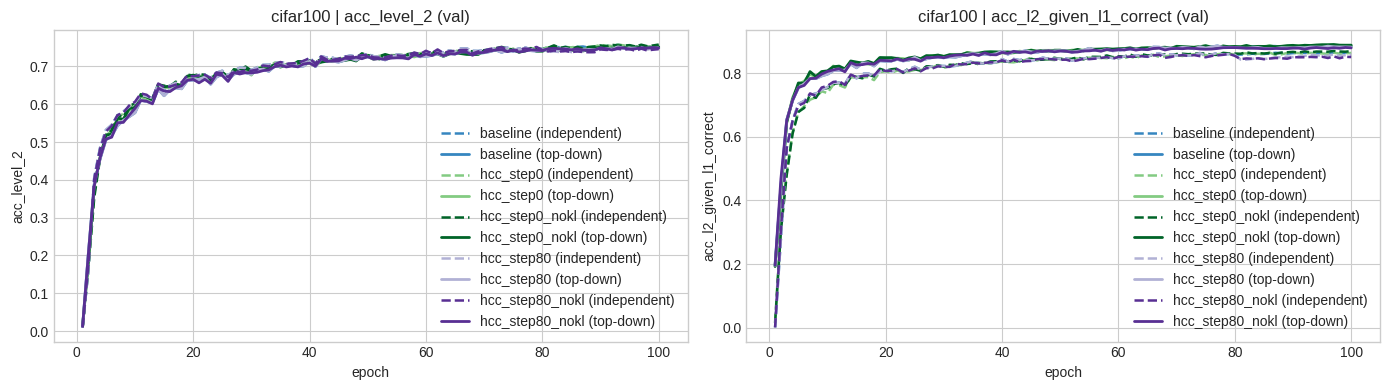

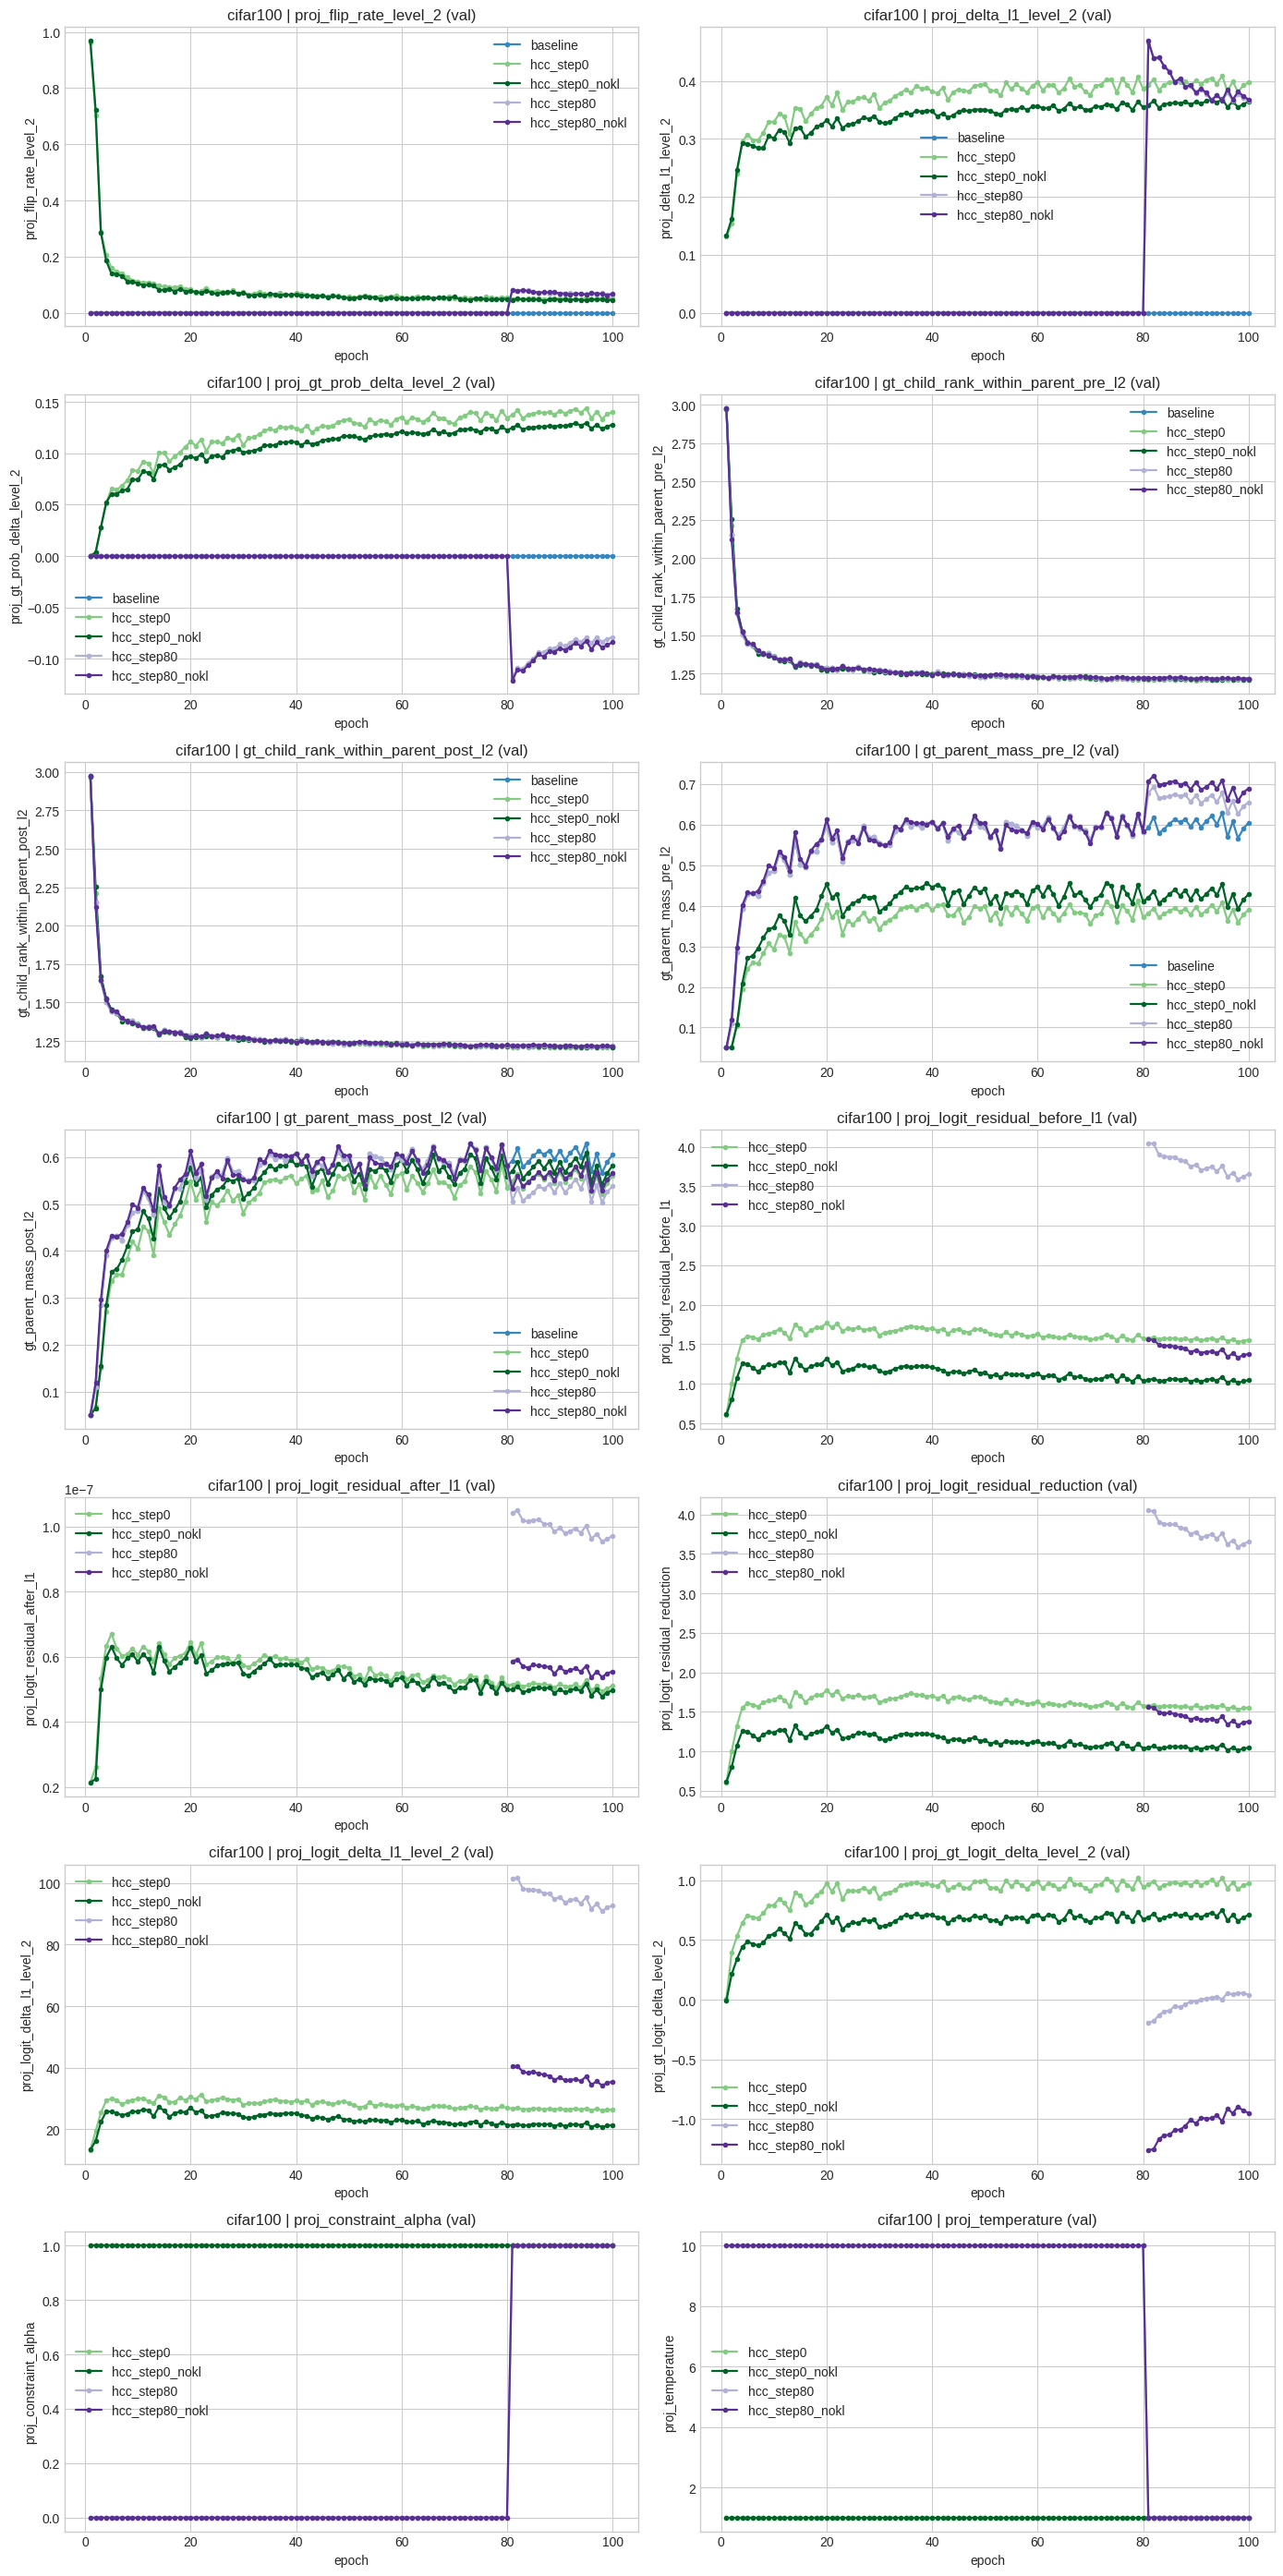

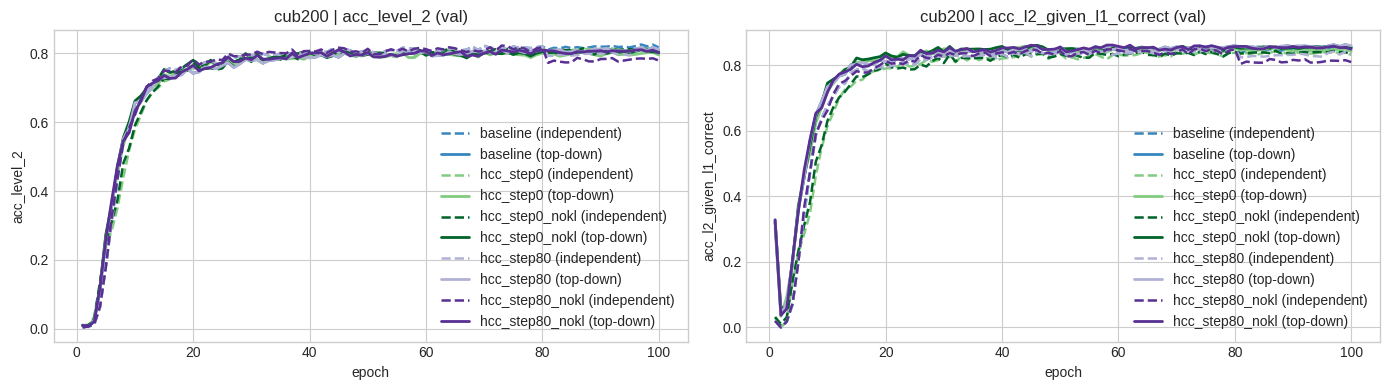

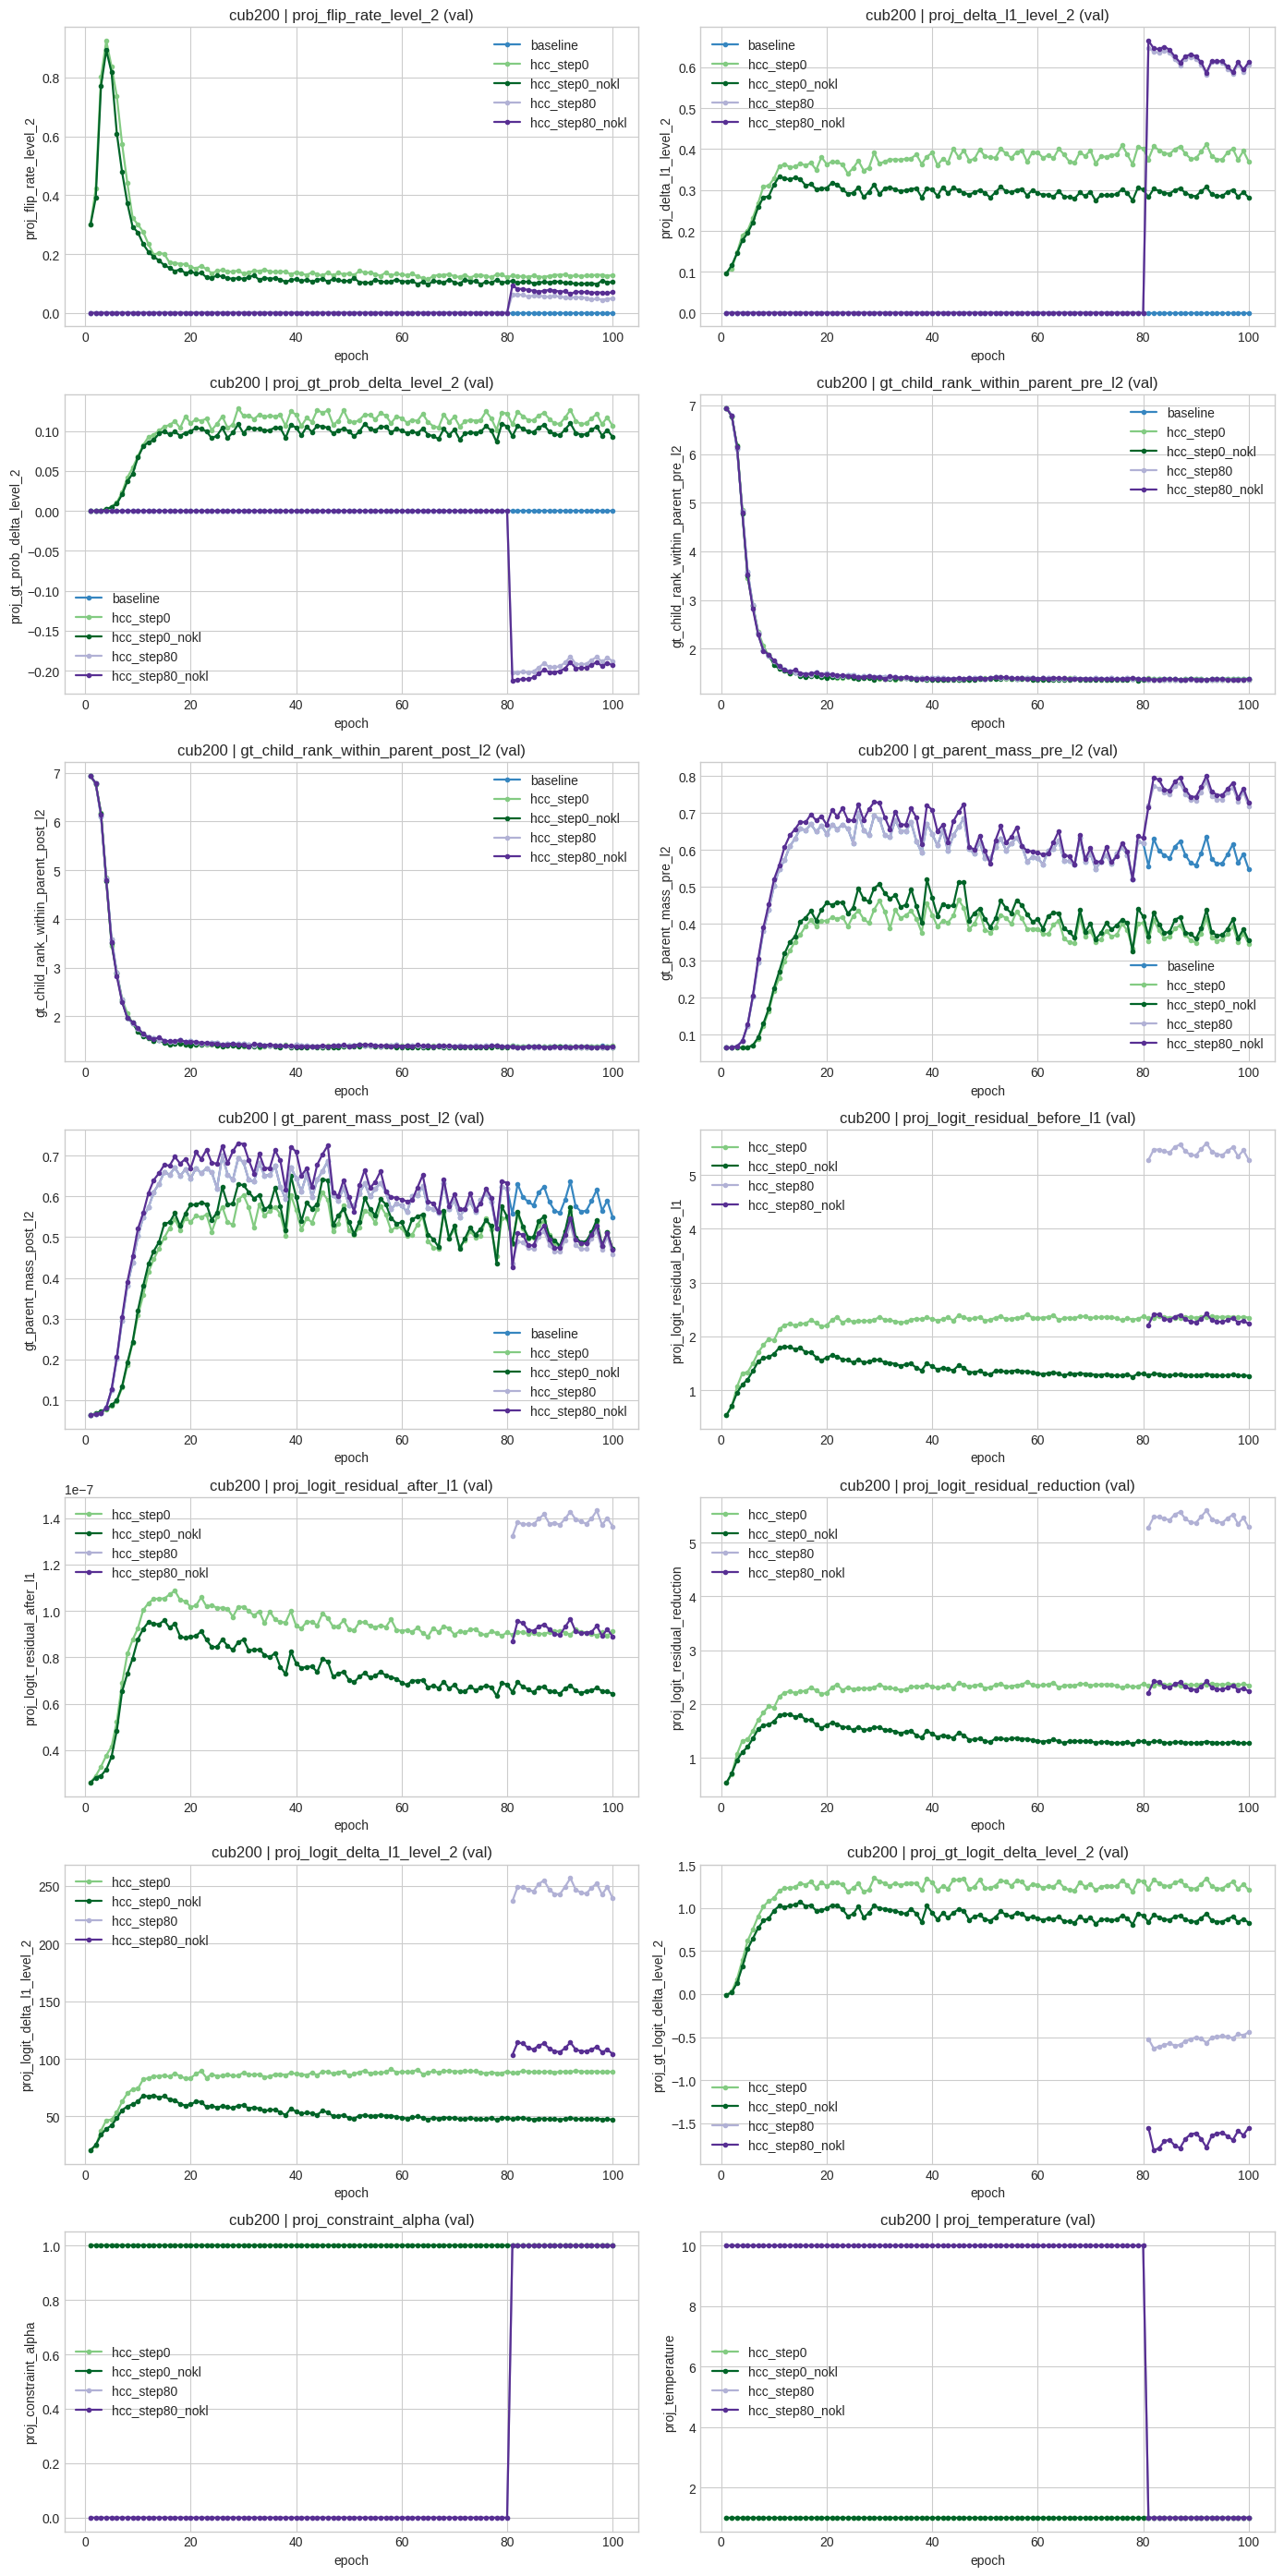

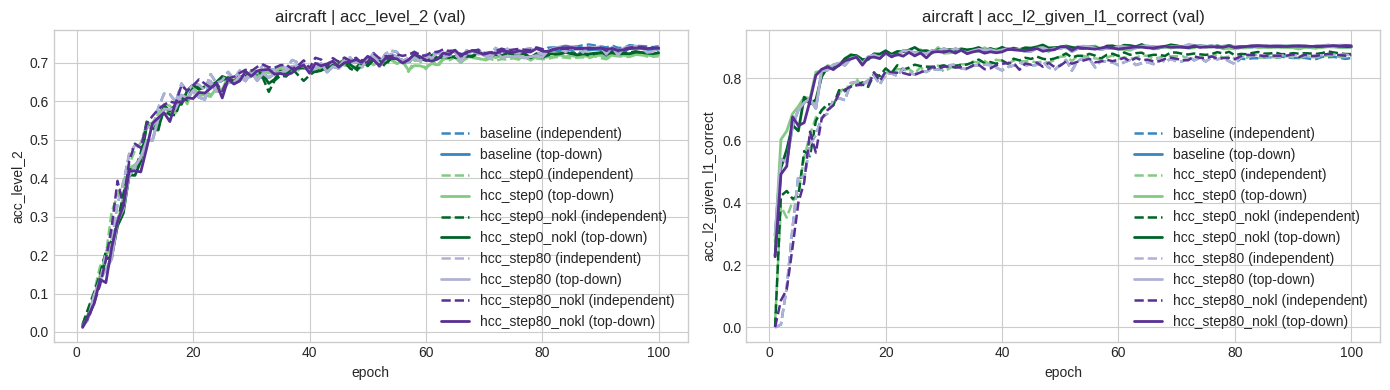

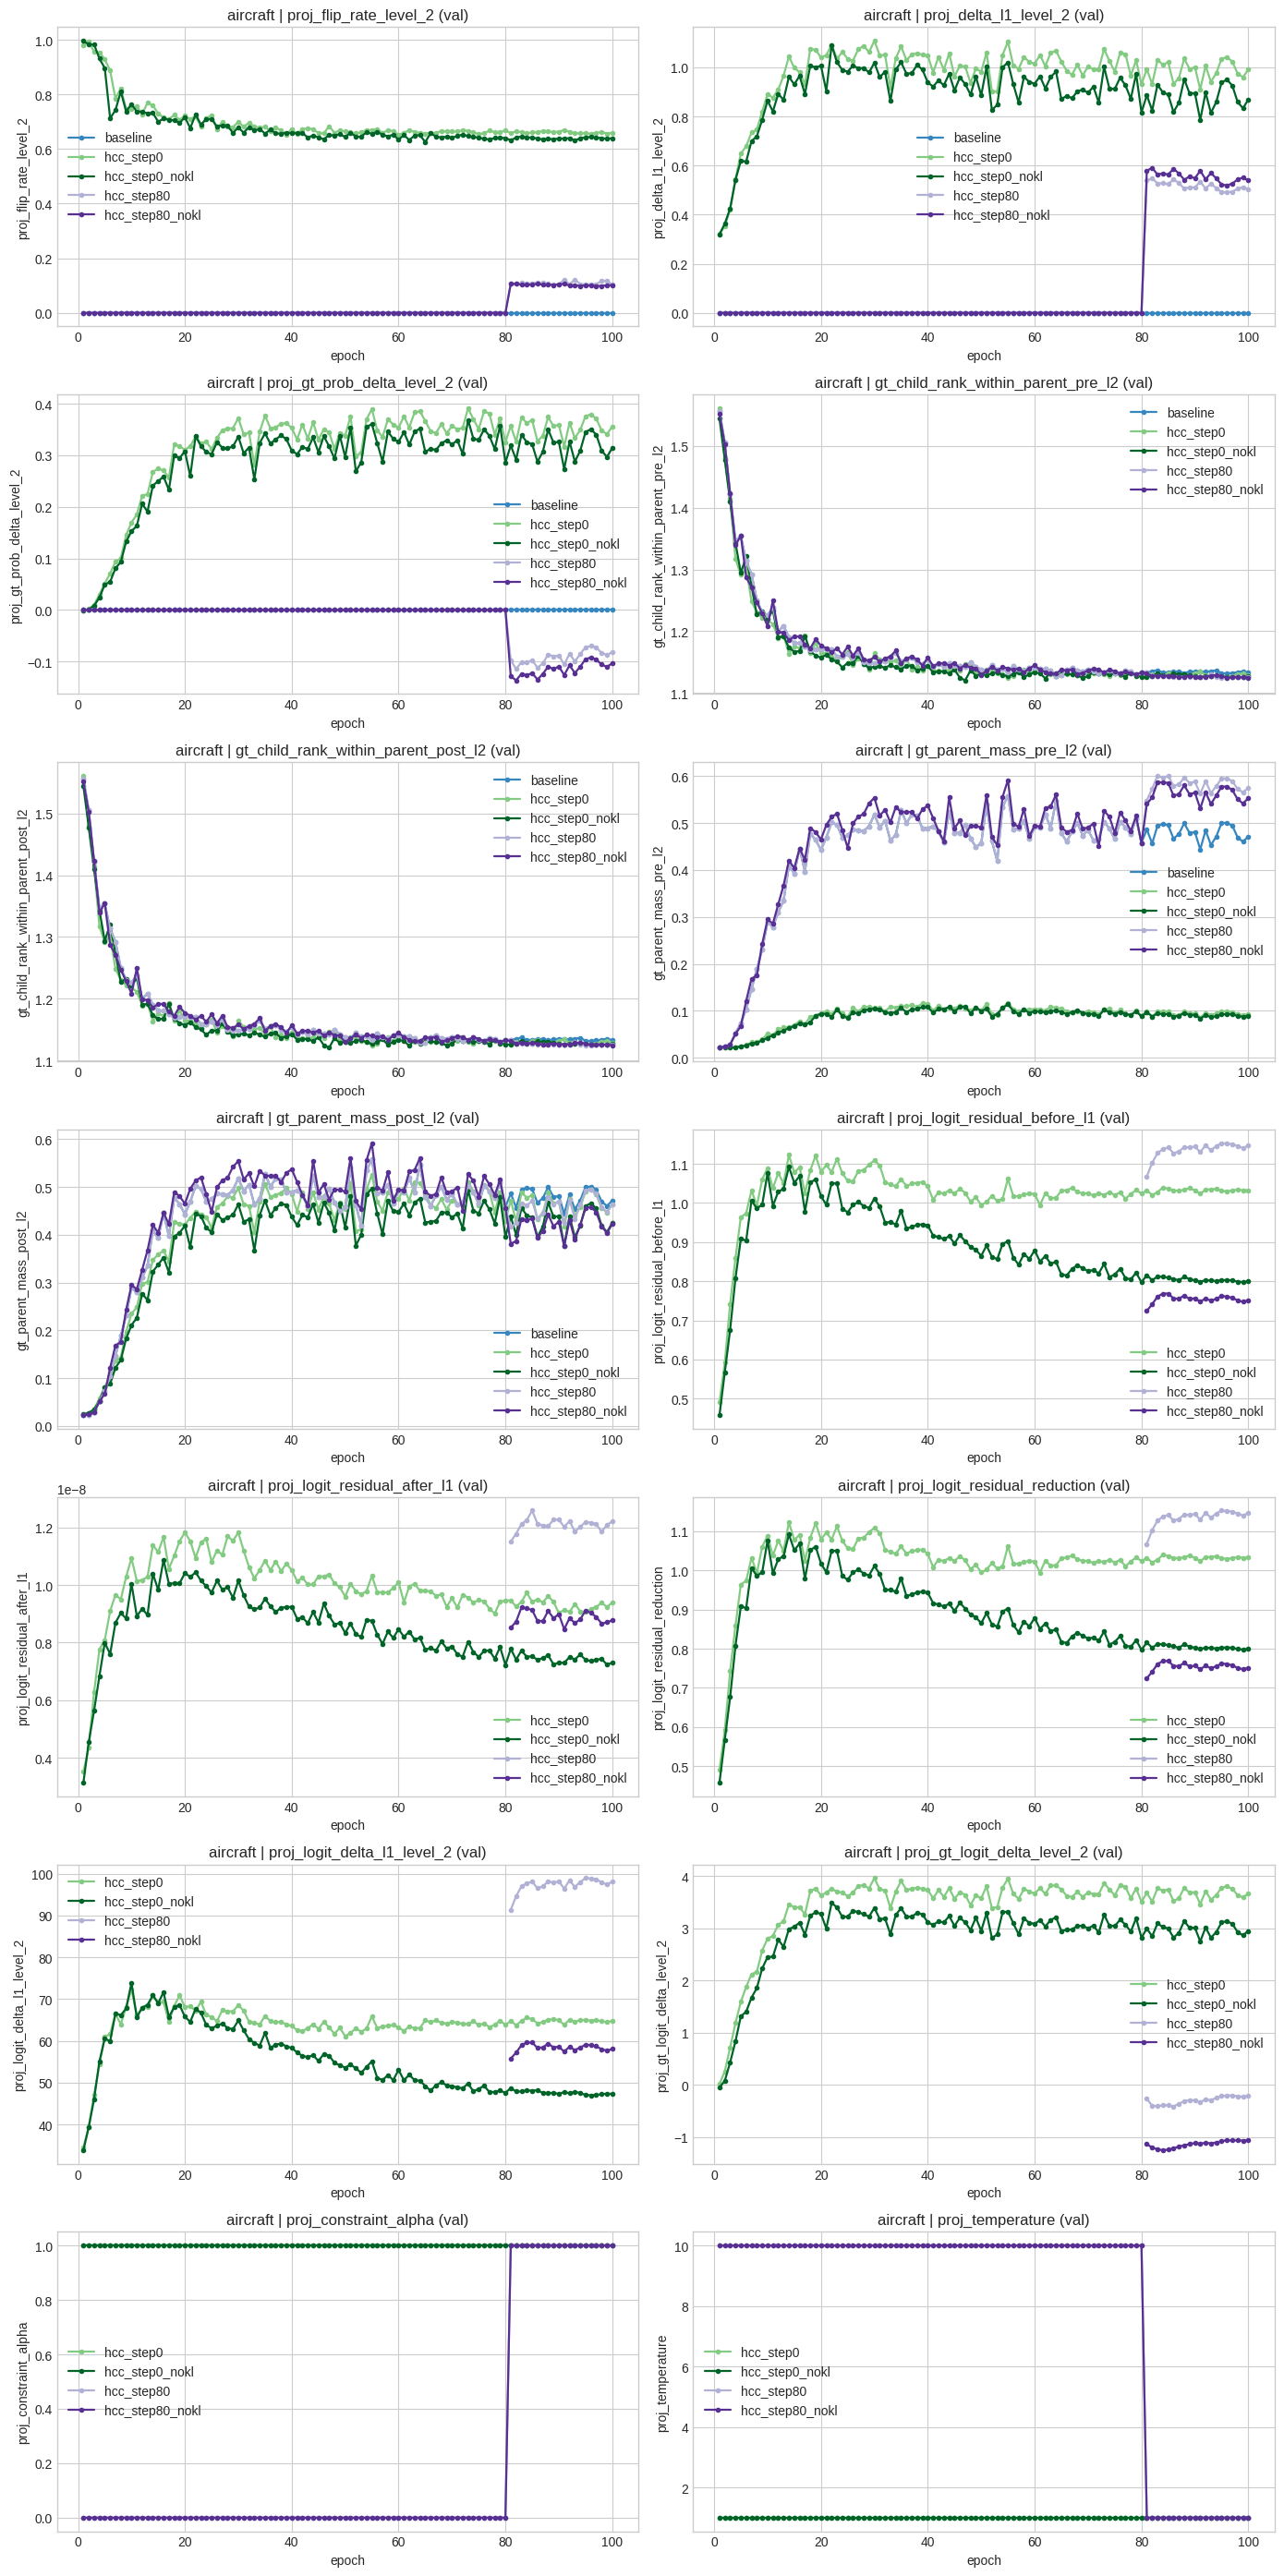

In [12]:
# 1) Overview of main metrics (val)
for ds in RUN_GROUPS:
    # independent vs top-down in the same panel
    plot_mode_pairs(
        ds,
        pair_specs=[
            ('acc_level_independent_2', 'acc_level_topdown_2', 'acc_level_2'),
            ('acc_l2_ind_given_l1_correct', 'acc_l2_td_given_l1_correct', 'acc_l2_given_l1_correct'),
        ],
        split='val',
        decoder_view=DECODER_VIEW,
    )

    # Other HCC diagnostics
    plot_metric_grid(
        ds,
        metrics=[
            'proj_flip_rate_level_2',
            'proj_delta_l1_level_2',
            'proj_gt_prob_delta_level_2',
            'gt_child_rank_within_parent_pre_l2',
            'gt_child_rank_within_parent_post_l2',
            'gt_parent_mass_pre_l2',
            'gt_parent_mass_post_l2',
            'proj_logit_residual_before_l1',
            'proj_logit_residual_after_l1',
            'proj_logit_residual_reduction',
            'proj_logit_delta_l1_level_2',
            'proj_gt_logit_delta_level_2',
            'proj_constraint_alpha',
            'proj_temperature',
        ],
        split='val',
    )
